## ¿Por qué usar Árboles de Decisión?

Los árboles de decisión ofrecen varias ventajas, entre ellas:

- Fácil interpretación: Son representables visualmente, lo que facilita su comprensión.

- Capacidad de manejar datos categóricos y numéricos.

- No requieren normalización de datos.

- Pueden manejar valores faltantes en algunos algoritmos como C4.5.



Aplicaciones de los Árboles de Decisión

- Medicina: Diagnóstico de enfermedades basado en síntomas.

- Finanzas: Predicción de clientes con alto riesgo de impago en préstamos.

- Marketing: Segmentación de clientes según su comportamiento de compra.

- Derecho: Clasificación de casos jurídicos en categorías específicas.

- Industria: Predicción de fallas en maquinarias con base en mediciones sensoriales.


Ejemplo Real

Un banco quiere determinar si un cliente debe recibir un préstamo.
Se pueden usar criterios como:

- Ingreso anual (¿superior a $50,000?)

- Historial de pagos (¿ha tenido deudas impagas?)

- Edad del cliente (¿es menor de 30 años?)

El modelo toma decisiones basadas en estos atributos y asigna una clasificación: "**Aprobado**" o "**Rechazado**".



### Sección 1: ¿Qué es un Árbol de Decisión?

Definición:

Un árbol de decisión es una técnica de aprendizaje supervisado utilizada para clasificación y regresión, donde los datos se dividen en ramas con base en preguntas sobre sus características.


**Estructura de un Árbol de Decisión**

Un árbol de decisión está compuesto por:

- **Nodo Raíz**: Representa el atributo principal sobre el cual se toma la primera decisión.

- **Nodos Intermedios** (de decisión): Representan criterios de partición sobre diferentes atributos.

- **Ramas**: Son las conexiones entre los nodos, representando una respuesta a la condición planteada en el nodo.

- **Nodos Hoja**: Representan la predicción final o resultado del modelo.

**Ejemplo**: Un Árbol de Decisión para Aprobar un Préstamo

- Si los ingresos son mayores a $50,000, se considera el historial crediticio.

- Si el historial es bueno, el préstamo es aprobado.

- Si cualquiera de estos factores es negativo, el préstamo es rechazado.

### Ejemplo de Código en Python – Visualización de un Árbol de Decisión



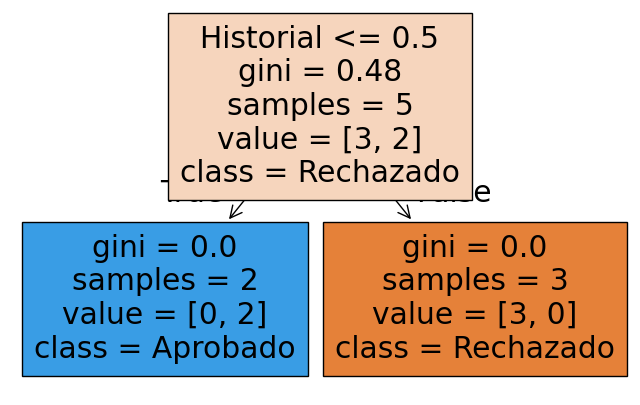

In [1]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Datos ficticios de ingresos y historial crediticio
X = [[60000, 1], [35000, 0], [80000, 1], [20000, 0], [50000, 1]]
y = ["Aprobado", "Rechazado", "Aprobado", "Rechazado", "Aprobado"]

# Crear y entrenar el árbol
tree = DecisionTreeClassifier(criterion="gini", max_depth=3)
tree.fit(X, y)

# Graficar el árbol
plt.figure(figsize=(8, 5))
plot_tree(tree, feature_names=["Ingreso", "Historial"],
          class_names=["Rechazado", "Aprobado"], filled=True)
plt.show()


**Conclusión**:

- El árbol de decisión divide los datos en ramas según condiciones lógicas.

- La representación gráfica ayuda a comprender fácilmente el proceso de toma de decisiones.

## 1.1. Tipos de Árboles de Decisión

**Árboles de Clasificación**: Se utilizan cuando la variable objetivo es categórica (Ejemplo: "Sí" o "No"). Utilizan métricas como Índice Gini o Entropía para determinar las divisiones óptimas.

**Ejemplo**: Diagnosticar si un paciente tiene una enfermedad (Sí/No).

**Árboles de Regresión**: Se utilizan cuando la variable objetivo es numérica continua. Utilizan métricas como Error Cuadrático Medio (MSE) para minimizar errores en predicciones.

**Ejemplo**: Predecir el precio de una casa en función de su tamaño y ubicación.

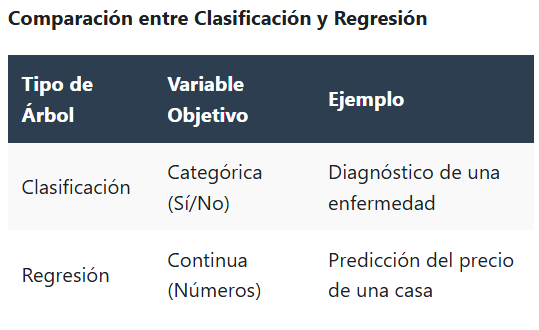

## Ejemplo de Código en Python – Comparación de Clasificación vs. Regresión

In [2]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# Datos simulados
X_class = np.array([[1], [2], [3], [4], [5]])
y_class = np.array(["Bajo", "Bajo", "Medio", "Alto", "Alto"])

X_reg = np.array([[1], [2], [3], [4], [5]])
y_reg = np.array([10000, 15000, 25000, 50000, 70000])

# Modelos
clf = DecisionTreeClassifier(max_depth=2).fit(X_class, y_class)
reg = DecisionTreeRegressor(max_depth=2).fit(X_reg, y_reg)

# Predicción de nuevos valores
print("Clasificación:", clf.predict([[3.5]]))  # Esperado: "Medio" o "Alto"
print("Regresión:", reg.predict([[3.5]]))       # Esperado: Un valor numérico intermedio

Clasificación: ['Medio']
Regresión: [25000.]


Conclusión:

- Los árboles de clasificación predicen categorías discretas (Ejemplo: "Bajo", "Medio", "Alto").

- Los árboles de regresión predicen valores continuos (Ejemplo: un precio en dólares).

## Ejercicio para la Sección 1

Objetivo: Comprender la diferencia entre árboles de clasificación y regresión.



Instrucciones:

- Cargar el dataset de precios de viviendas (sns.load_dataset("house_prices")).

- Entrenar un árbol de clasificación para predecir si una casa es "barata" o "cara".

- Entrenar un árbol de regresión para predecir el precio exacto de la casa.

- Comparar ambos enfoques y explicar sus diferencias

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# Dataset de Kaggle
# Link: https://www.kaggle.com/datasets/fratzcan/usa-house-prices
dat_csv = pd.read_csv("USA Housing Dataset.csv", encoding = "ISO-8859-1")


dat_csv_limpio = dat_csv[["price", "bedrooms", "bathrooms", "floors"]]
dat_csv_limpio.head()

# Columna nueva de tipo si es casa barata o cara, poniendo la media como parametro
precio_medio = dat_csv_limpio["price"].median()
dat_csv_limpio["tipo"] = np.where(dat_csv_limpio["price"] >= precio_medio, "cara", "barata")
dat_csv_limpio

# Variables de Regresión
X_reg = dat_csv_limpio[["bedrooms", "bathrooms", "floors"]]
y_reg = dat_csv_limpio["price"]

# Variables de Clasificación
X_class = dat_csv_limpio[["bedrooms", "bathrooms", "floors"]]
y_class = dat_csv_limpio["tipo"]

clf = DecisionTreeClassifier(max_depth=2).fit(X_class, y_class)
reg = DecisionTreeRegressor(max_depth=2).fit(X_reg, y_reg)

# Predecir 3 habitaciones, 2 baños y 1 piso
nuevo_dato = [[3, 2, 1]]

print("Clasificación (Tipo):", clf.predict(nuevo_dato))
print("Regresión (Precio):", reg.predict(nuevo_dato))
print("La casa es: " + clf.predict(nuevo_dato), " y su precio es de: " + str(reg.predict(nuevo_dato)))



Clasificación (Tipo): ['barata']
Regresión (Precio): [576539.62450697]
['La casa es: barata']  y su precio es de: [576539.62450697]


/tmp/ipykernel_2535/4092598868.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat_csv_limpio["tipo"] = np.where(dat_csv_limpio["price"] >= precio_medio, "cara", "barata")
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  w

Preguntas de Reflexión:

¿Cuándo es más útil un árbol de clasificación en lugar de uno de regresión?

- Es más útil uno de regresión para la presición, sin embargo creo que uno de clasificación es mejor para una rapida clasificación u optimización del modelo.

¿Cómo afecta la profundidad del árbol a la precisión del modelo?

- La profundidad afecta mucho, pongamos el ejemplo que poca profundidad es un modelo muy malo, con mucha profundidad se vuelve muy bueno para algunas cosas pero empieza a confundirse con toda la información y es algo contraproducente, mientras que una profundidad exacta hace que el modelo sea bueno y no tenga estos problemas y se pueda adaptar correctamente a la información.

¿Cómo podríamos mejorar la predicción con más atributos?

- Podríamos mejorar la predicción columnas relacionadas con la variable a predecir, información numérica como por ejemplo el FOT y el FOS del terreno podrían ser útiles para mejorar la precisión del modelo.

2.2. Algoritmos Populares para Construcción de Árboles

ID3 (Iterative Dichotomiser 3): Utiliza Ganancia de Información basada en Entropía para seleccionar los mejores atributos. Limitaciones: No maneja atributos numéricos ni valores faltantes. Ejemplo de Aplicación: Clasificación de correos en spam y no spam.

C4.5: Es una mejora de ID3 que puede manejar atributos numéricos y datos faltantes. Utiliza Índice de Ganancia, que ajusta la ganancia de información para evitar sesgos hacia atributos con muchos valores. Ejemplo de Aplicación: Diagnóstico médico basado en síntomas.

CART (Classification and Regression Trees): Utiliza Índice Gini en clasificación y MSE en regresión. Solo genera árboles binarios (cada nodo tiene exactamente dos ramas). Ejemplo de Aplicación: Predicción de precios de viviendas.


2.3. Implementación en Python: Comparación de Algoritmos

Ejemplo: Comparar ID3 y CART en Clasificación

In [4]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Cargar dataset Titanic
df = sns.load_dataset("titanic").dropna()

# Preprocesamiento
df["sex"] = df["sex"].map({"male": 1, "female": 0})
X = df[["age", "fare", "sex", "class"]]
y = df["survived"]

# Convertir "class" en variable numérica
X = pd.get_dummies(X, drop_first=True)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Árbol ID3 (simulado con entropy en scikit-learn)
tree_id3 = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
tree_id3.fit(X_train, y_train)
y_pred_id3 = tree_id3.predict(X_test)

# Árbol CART (scikit-learn usa Gini por defecto)
tree_cart = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
tree_cart.fit(X_train, y_train)
y_pred_cart = tree_cart.predict(X_test)

# Evaluación de precisión
print("Precisión ID3 (Entropía):", accuracy_score(y_test, y_pred_id3))
print("Precisión CART (Gini):", accuracy_score(y_test, y_pred_cart))


Precisión ID3 (Entropía): 0.7027027027027027
Precisión CART (Gini): 0.7027027027027027


Conclusión:

ID3 usa Entropía y suele generar árboles más grandes y detallados.

CART usa Gini y tiende a ser más eficiente en árboles binarios.


### Ejercicio para la Sección 2


Objetivo: Comparar ID3 y CART en un dataset real.

Instrucciones:

Cargar el dataset sns.load_dataset("penguins").

Aplicar un árbol ID3 (criterion="entropy") para predecir la especie del pingüino.

Aplicar un árbol CART (criterion="gini") con los mismos datos.

Comparar las precisiones de ambos modelos.



In [32]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Cargar dataset Titanic
df = sns.load_dataset("penguins").dropna()

# Preprocesamiento
df["species"] = df["species"].map({"Adelie":2, "Chinstrap": 1, "Gentoo": 0})

X = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]
y = df["species"]

# Convertir "class" en variable numérica
X = pd.get_dummies(X, drop_first=True)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Árbol ID3 (simulado con entropy en scikit-learn)
tree_id3 = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
tree_id3.fit(X_train, y_train)
y_pred_id3 = tree_id3.predict(X_test)

# Árbol CART (scikit-learn usa Gini por defecto)
tree_cart = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
tree_cart.fit(X_train, y_train)
y_pred_cart = tree_cart.predict(X_test)


# Evaluación de precisión
print("Precisión ID3 (Entropía):", accuracy_score(y_test, y_pred_id3))
print("Precisión CART (Gini):", accuracy_score(y_test, y_pred_cart))


Precisión ID3 (Entropía): 0.9701492537313433
Precisión CART (Gini): 0.9850746268656716


**Preguntas de Reflexión**:

¿Qué algoritmo fue más preciso en este dataset?

- Cuando realicé la práctica con el data set de pinguinos encontré que el modelo de ID3 es más precizo que CART



¿Cómo influye la profundidad máxima del
árbol en la precisión?

- Influye aumentando la presición del modelo, sin embargo a veces es contraproducente, en nuestro caso


¿Cómo podríamos mejorar estos modelos?

Luego de investigar, podríamos:

- Optimizar Hiperparámetros (Usar GridSearch, para probar automáticamente combinacionés, gini vs entropy)

- Evaluar más alla de la precisión (precisión, recall, F1-score)

- Prevenir sobreajuste (ajustar parametros de regularización)

- Probar otros algoritmos, es decir comparar el árbol con random forest o gradient boosting

- Analizar características

## Sección 3: Evaluación y Optimización de Árboles de Decisión



Objetivo:

Aprender a evaluar la calidad de un árbol de decisión y explorar técnicas para optimizar su desempeño.



### 3.1. ¿Cómo Evaluar un Árbol de Decisión?

**Para Árboles de Clasificación:**

- Precisión (Accuracy): Proporción de predicciones correctas.

- Matriz de Confusión: Muestra los verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.

- Precision, Recall y F1-score: Métricas clave para evaluar la calidad de la clasificación.

- Curva ROC-AUC: Indica la capacidad del modelo para separar las clases.

**Para Árboles de Regresión:**

- Coeficiente de Determinación (R²): Indica qué porcentaje de la variabilidad en los datos es explicada por el modelo.

- Error Cuadrático Medio (MSE): Mide el promedio de los errores al cuadrado.

- Error Absoluto Medio (MAE): Mide el error medio en términos absolutos.

**Actividad: Evaluación de un Árbol de Clasificación en Python**

Precisión del Árbol de Decisión: 0.9850746268656716

Matriz de Confusión:
 [[30  1  0]
 [ 0 13  0]
 [ 0  0 23]]

Reporte de Clasificación:
               precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        31
   Chinstrap       0.93      1.00      0.96        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



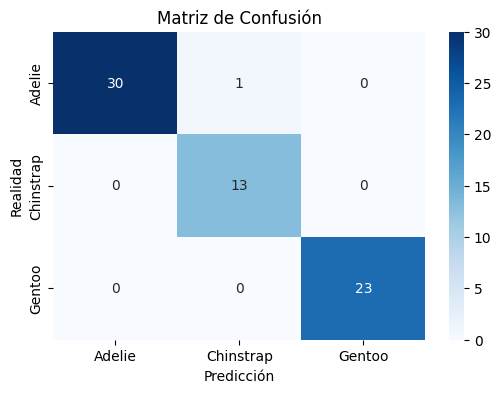

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluación del modelo
y_pred = tree_cart.predict(X_test)
print("Precisión del Árbol de Decisión:", accuracy_score(y_test, y_pred))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

# Visualización de la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=y.unique(), yticklabels=y.unique())
plt.xlabel("Predicción")
plt.ylabel("Realidad")
plt.title("Matriz de Confusión")
plt.show()


Conclusión:

La matriz de confusión ayuda a visualizar los errores del modelo.

Precisión y F1-score son útiles para evaluar el desempeño en clasificación.




### 3.2. Problemas Comunes en Árboles de Decisión

1. Sobreajuste (Overfitting): Ocurre cuando el árbol es demasiado profundo y aprende patrones específicos del dataset de entrenamiento, reduciendo su capacidad de generalizar.

**Solución:** Limitar la profundidad máxima (max_depth), el número mínimo de observaciones en un nodo (min_samples_split) y usar poda.

2. **Subajuste (Underfitting):** Ocurre cuando el árbol es demasiado simple y no capta bien las relaciones en los datos.

**Solución:** Aumentar la profundidad del árbol o incluir más variables predictoras.

3. **Selección de Atributos No Relevantes:** Si el árbol usa atributos irrelevantes, puede generar predicciones inconsistentes.

**Solución:** Aplicar selección de características para elegir solo las más importantes.

4. **Sensibilidad a los Datos Desequilibrados:** Si hay clases desbalanceadas, el árbol puede favorecer la clase mayoritaria.

**Solución:** Aplicar técnicas como balanceo de datos o ponderación de clases.

### 3.3. Optimización de Árboles de Decisión

1. Ajuste de Parámetros (Hyperparameter Tuning)

Se pueden optimizar los parámetros del árbol para evitar sobreajuste o subajuste:



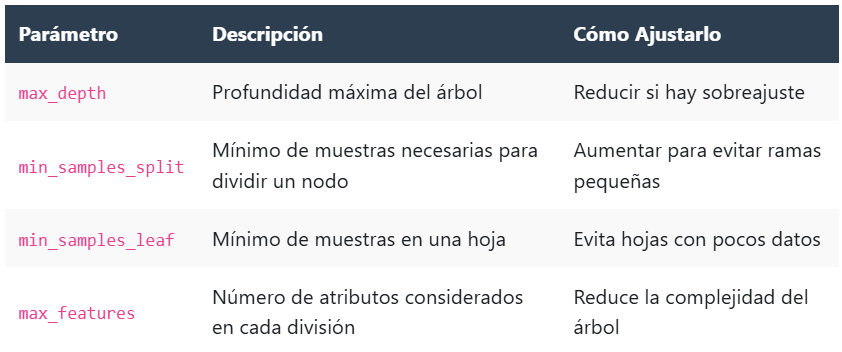

### Ejemplo: Ajuste Manual de Parámetros



In [8]:
tree_optimized = DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                        min_samples_leaf=5, random_state=42)
tree_optimized.fit(X_train, y_train)
y_pred_opt = tree_optimized.predict(X_test)
print("Precisión optimizada:", accuracy_score(y_test, y_pred_opt))


Precisión optimizada: 0.9850746268656716


2. Búsqueda de Parámetros con GridSearchCV

Se puede automatizar la búsqueda de los mejores parámetros con GridSearchCV.




In [9]:
from sklearn.model_selection import GridSearchCV

# Definir parámetros
param_grid = {
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}

# Aplicar GridSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)
print("Mejores parámetros:", grid_search.best_params_)


Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}


3. Poda de Árboles

- Poda previa (Pre-pruning): Limita la profundidad del árbol durante su construcción (max_depth).

- Poda posterior (Post-pruning): Permite que el árbol crezca completamente y luego elimina ramas innecesarias.



### Actividad extensiva: Poda de un Árbol



In [10]:
from sklearn.tree import export_text

# Mostrar el árbol antes de poda
print(export_text(tree_cart, feature_names=X.columns.tolist()))

# Aplicar poda reduciendo max_depth
tree_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_pruned.fit(X_train, y_train)

# Mostrar el árbol después de la poda
print(export_text(tree_pruned, feature_names=X.columns.tolist()))


|--- flipper_length_mm <= 206.50
|   |--- bill_length_mm <= 43.35
|   |   |--- bill_length_mm <= 42.35
|   |   |   |--- bill_depth_mm <= 16.70
|   |   |   |   |--- class: Adelie
|   |   |   |--- bill_depth_mm >  16.70
|   |   |   |   |--- class: Adelie
|   |   |--- bill_length_mm >  42.35
|   |   |   |--- bill_depth_mm <= 17.90
|   |   |   |   |--- class: Chinstrap
|   |   |   |--- bill_depth_mm >  17.90
|   |   |   |   |--- class: Adelie
|   |--- bill_length_mm >  43.35
|   |   |--- body_mass_g <= 4100.00
|   |   |   |--- class: Chinstrap
|   |   |--- body_mass_g >  4100.00
|   |   |   |--- bill_length_mm <= 48.80
|   |   |   |   |--- class: Adelie
|   |   |   |--- bill_length_mm >  48.80
|   |   |   |   |--- class: Chinstrap
|--- flipper_length_mm >  206.50
|   |--- bill_depth_mm <= 17.65
|   |   |--- class: Gentoo
|   |--- bill_depth_mm >  17.65
|   |   |--- bill_depth_mm <= 18.95
|   |   |   |--- class: Adelie
|   |   |--- bill_depth_mm >  18.95
|   |   |   |--- class: Chinstrap

|

Conclusión:

- Ajustar max_depth, min_samples_split y min_samples_leaf mejora la generalización del modelo.

- GridSearchCV permite encontrar la mejor configuración automáticamente.

- La poda de árboles evita que el modelo aprenda ruido en los datos.


### Actividad para la Sección 3

Objetivo: Optimizar un Árbol de Decisión para mejorar su desempeño.

Instrucciones:

1. Cargar el dataset de "diabetes" (sns.load_dataset("diabetes")).

2. Entrenar un árbol de decisión estándar y medir su precisión.

3. Optimizar max_depth y min_samples_split usando GridSearchCV.

4. Comparar el desempeño del modelo original vs. el optimizado.

In [38]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes
import pandas as pd

# Cargar dataset de diabetes desde Scikit-learn
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

X = df.drop(columns=["target"])
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Árbol Estandar
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

# Predicción del Árbol
y_pred_basic = tree.predict(X_test)
print(f"MSE Árbol Estandar: {mean_squared_error(y_test, y_pred_basic):.2f}")
print(f"R2 Score Árbol Estandar: {r2_score(y_test, y_pred_basic):.2f}")

# Definir parámetros para GridSearchCV
param_grid = {
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}

# GridSearchCV
grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring="neg_mean_squared_error")
grid_search.fit(X_train, y_train)

# Evaluar modelo optimizado
best_tree = grid_search.best_estimator_
y_pred_optimized = best_tree.predict(X_test)
print(f"\nMejores parámetros: {grid_search.best_params_}")
print(f"MSE Árbol Optimizado: {mean_squared_error(y_test, y_pred_optimized):.2f}")
print(f"R2 Score Árbol Optimizado: {r2_score(y_test, y_pred_optimized):.2f}")

MSE Árbol Estandar: 4976.80
R2 Score Árbol Estandar: 0.06

Mejores parámetros: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
MSE Árbol Optimizado: 3094.50
R2 Score Árbol Optimizado: 0.42


Preguntas de Reflexión:

¿Cómo cambió la precisión después de la optimización?

- Mejoró notoriamente, el primer valor MSE, que es el error cuadrático medio del Árbol Básico, encontramos un valor de 4976, lo que indica que los valores se desvían mucho de los valores reales. El R2 nos indica que 6% del modelo nos explica la varianza de los datos. Luego de optimizarlos vemos que el MSE baja lo que es positivo, el error cuadrático medio es más bajo a comparación del primer modelo y el R2 ahora encontramos que el 42% del modelo explica la varianza de los datos.


¿Qué parámetros fueron más importantes en la mejora del modelo?

- Considero que los más importantes fueron "max_depth" ya que entre los valores 3, 5 y 10 encontró el mejor parámetro era 3, y "min_samples_split" en donde también, encontró que el mejor parámetro era el más bajo, el 2.

¿Cómo afecta la poda al rendimiento del árbol?

- Afecta positivamente en la simplicidad del entendimiento del modelo, hace que el ruido no lo detecte y las predicciones sean más efectivas, esto se puede observar en el valor de r2.


In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Simulación de datos de clientes
data = {
    "Edad": np.random.randint(20, 65, 500),
    "Ingresos": np.random.randint(20000, 120000, 500),
    "Historial": np.random.randint(0, 5, 500),
    "Monto_Credito": np.random.randint(5000, 50000, 500),
    "Incumplimiento": np.random.choice([0, 1], size=500, p=[0.7, 0.3])  # 30% de incumplimiento
}
df = pd.DataFrame(data)

# Dividir en entrenamiento y prueba
X = df.drop(columns=["Incumplimiento"])
y = df["Incumplimiento"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar Árbol de Decisión Básico
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Predicciones y evaluación
y_pred = tree.predict(X_test)
print("Precisión Árbol de Decisión:", accuracy_score(y_test, y_pred))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

# Optimización con GridSearchCV
param_grid = {
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)

# Evaluar Árbol Optimizado
best_tree = grid_search.best_estimator_
y_pred_opt = best_tree.predict(X_test)
print("\nPrecisión Árbol Optimizado:", accuracy_score(y_test, y_pred_opt))

# Comparación con Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\nPrecisión Random Forest:", accuracy_score(y_test, y_pred_rf))


Precisión Árbol de Decisión: 0.5

Matriz de Confusión:
 [[46 23]
 [27  4]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.63      0.67      0.65        69
           1       0.15      0.13      0.14        31

    accuracy                           0.50       100
   macro avg       0.39      0.40      0.39       100
weighted avg       0.48      0.50      0.49       100


Precisión Árbol Optimizado: 0.68

Precisión Random Forest: 0.65
